# Setup

In [5]:
import pandas as pd

# 1. Load the CSV files
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

# 2. Inspect shape (Rows, Columns)
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

# 3. View the first few rows
print("\n--- Train First 5 Rows ---")
print(train.head())

# 4. Check data types and missing values
print("\n--- Data Summary ---")
print(train.info())

# 5. Check the target distribution
print("\n--- Target Balance ---")
print(train["Heart Disease"].value_counts(normalize=True))

Train shape: (630000, 15)
Test shape:  (270000, 14)

--- Train First 5 Rows ---
   id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   0   58    1                4  152          239             0            0   
1   1   52    1                1  125          325             0            2   
2   2   56    0                2  160          188             0            2   
3   3   44    0                3  134          229             0            2   
4   4   58    1                4  140          234             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     158                1            3.6            2   
1     171                0            0.0            1   
2     151                0            0.0            1   
3     150                0            1.0            2   
4     125                1            3.8            2   

   Number of vessels fluro  Thallium Heart Disease  
0                        2     

# Data Preprocessing & Encoding

In [7]:
# 1. Map target string values to 1 and 0
target_map = {"Presence": 1, "Absence": 0}
train["Heart Disease"] = train["Heart Disease"].map(target_map)

# 2. Separate features (X) and target (y)
X = train.drop(columns=["id", "Heart Disease"])
y = train["Heart Disease"]

# Features for the test set (drop 'id' column)
X_test = test.drop(columns=["id"])

print("Target mapped successfully!")
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Target mapped successfully!
X shape: (630000, 13)
y distribution:
 Heart Disease
0    347546
1    282454
Name: count, dtype: int64


## Exploratory Data Analysis (EDA) - Visualizing Dataset Insights

C:\Users\rocky\AppData\Local\Temp\ipykernel_9328\486299414.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Heart Disease', palette='Set2')  # <-- Fixed column name here


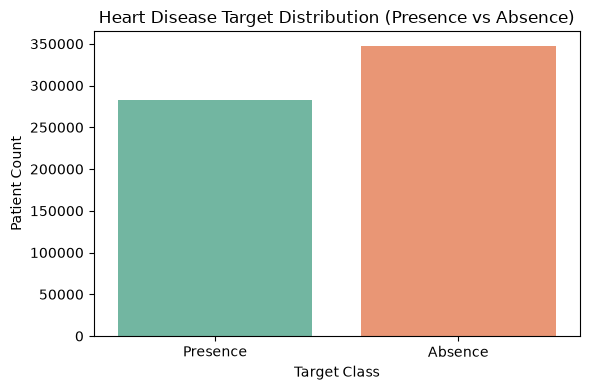

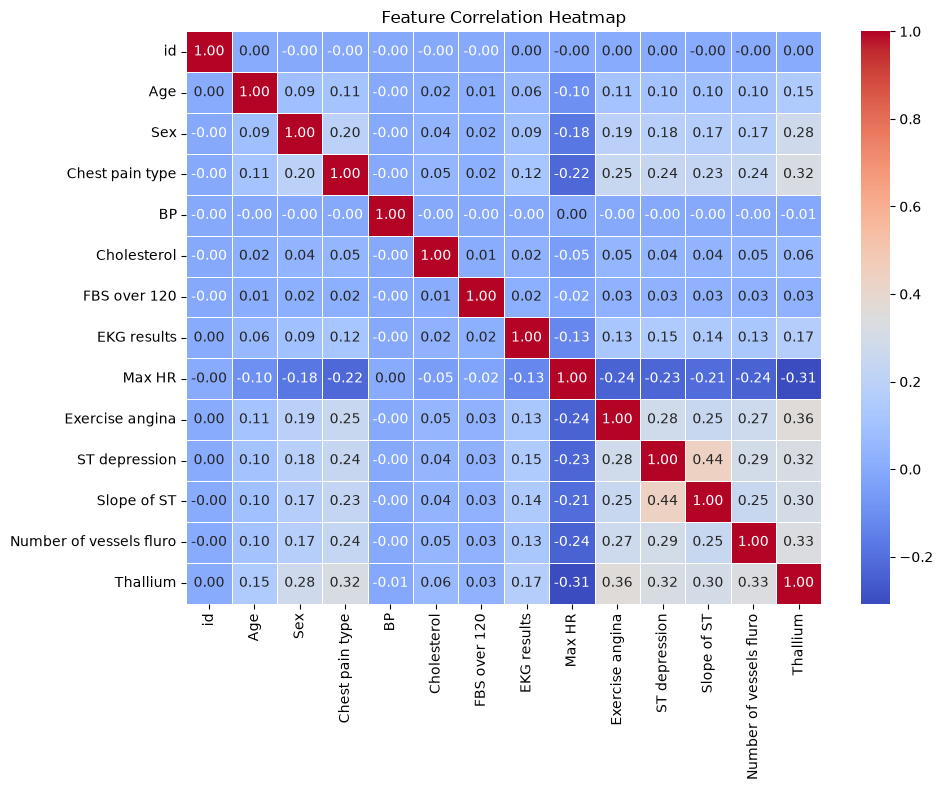

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load your dataset
df = pd.read_csv('train.csv')

# --- CHART 1: Target Class Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Heart Disease', palette='Set2')  # <-- Fixed column name here
plt.title('Heart Disease Target Distribution (Presence vs Absence)')
plt.xlabel('Target Class')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300)
plt.show()

# --- CHART 2: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

# Train Tuned LightGBM & Generate Predictions

In [8]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# 1. Load clean data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target_map = {"Presence": 1, "Absence": 0}
train["Heart Disease"] = train["Heart Disease"].map(target_map)

X = train.drop(columns=["id", "Heart Disease"])
y = train["Heart Disease"]
X_test = test.drop(columns=["id"])

# 2. Plug in Optuna's best hyperparameters
tuned_lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,          # Increased estimators for refined learning
    'learning_rate': 0.063114,
    'num_leaves': 71,
    'max_depth': 5,
    'min_child_samples': 111,
    'subsample': 0.693091,
    'colsample_bytree': 0.528857,
    'reg_alpha': 1.337258e-08,
    'reg_lambda': 7.169018,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_lgb_oof = np.zeros(len(train))
tuned_lgb_test = np.zeros(len(test))

print("--- Training Tuned LightGBM Across 5 Folds ---")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**tuned_lgb_params)
    model.fit(X_train, y_train)

    val_probs = model.predict_proba(X_val)[:, 1]
    tuned_lgb_oof[val_idx] = val_probs
    tuned_lgb_test += model.predict_proba(X_test)[:, 1] / skf.n_splits

    fold_score = roc_auc_score(y_val, val_probs)
    print(f"Fold {fold + 1} ROC-AUC: {fold_score:.5f}")

overall_score = roc_auc_score(y, tuned_lgb_oof)
print(f"\n---> Tuned LightGBM Final OOF Score: {overall_score:.5f} <---")

# Save standalone tuned submission
submission_tuned = pd.DataFrame({"id": test["id"], "Heart Disease": tuned_lgb_test})
submission_tuned.to_csv("tuned_lgb_submission.csv", index=False)
print("Saved tuned_lgb_submission.csv successfully!")

--- Training Tuned LightGBM Across 5 Folds ---
Fold 1 ROC-AUC: 0.95575
Fold 2 ROC-AUC: 0.95468
Fold 3 ROC-AUC: 0.95549
Fold 4 ROC-AUC: 0.95511
Fold 5 ROC-AUC: 0.95592

---> Tuned LightGBM Final OOF Score: 0.95539 <---
Saved tuned_lgb_submission.csv successfully!


# Train Tuned XGBoost & Generate Predictions

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# Load clean data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

target_map = {"Presence": 1, "Absence": 0}
train["Heart Disease"] = train["Heart Disease"].map(target_map)

X = train.drop(columns=["id", "Heart Disease"])
y = train["Heart Disease"]
X_test = test.drop(columns=["id"])

# Tuned XGBoost parameters from Optuna
tuned_xgb_params = {
    "n_estimators": 1000,  # Increased estimators for smoother predictions
    "learning_rate": 0.033101,
    "max_depth": 7,
    "min_child_weight": 7,
    "subsample": 0.692087,
    "colsample_bytree": 0.619661,
    "gamma": 0.000276,
    "reg_alpha": 7.562617,
    "reg_lambda": 6.92744e-06,
    "tree_method": "hist",
    "eval_metric": "auc",
    "random_state": 42,
    "n_jobs": -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_xgb_oof = np.zeros(len(train))
tuned_xgb_test = np.zeros(len(test))

print("--- Training Tuned XGBoost Across 5 Folds ---")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = XGBClassifier(**tuned_xgb_params)
    model.fit(X_train, y_train)

    val_probs = model.predict_proba(X_val)[:, 1]
    tuned_xgb_oof[val_idx] = val_probs
    tuned_xgb_test += model.predict_proba(X_test)[:, 1] / skf.n_splits

    fold_score = roc_auc_score(y_val, val_probs)
    print(f"Fold {fold + 1} ROC-AUC: {fold_score:.5f}")

overall_xgb_score = roc_auc_score(y, tuned_xgb_oof)
print(f"\n---> Tuned XGBoost Final OOF Score: {overall_xgb_score:.5f} <---")

--- Training Tuned XGBoost Across 5 Folds ---
Fold 1 ROC-AUC: 0.95560
Fold 2 ROC-AUC: 0.95454
Fold 3 ROC-AUC: 0.95535
Fold 4 ROC-AUC: 0.95496
Fold 5 ROC-AUC: 0.95576

---> Tuned XGBoost Final OOF Score: 0.95524 <---


# Ultimate Tuned Ensemble (Tuned LGBM + Tuned XGB)

In [11]:
# Blend both tuned model predictions (Requires tuned_lgb_oof and tuned_lgb_test from earlier)
ultimate_blend_oof = (0.55 * tuned_lgb_oof) + (0.45 * tuned_xgb_oof)
ultimate_blend_score = roc_auc_score(y, ultimate_blend_oof)

print("==================================================")
print(f"Tuned LightGBM OOF Score : {roc_auc_score(y, tuned_lgb_oof):.5f}")
print(f"Tuned XGBoost  OOF Score : {overall_xgb_score:.5f}")
print(
    f"---> ULTIMATE TUNED ENSEMBLE OOF SCORE: {ultimate_blend_score:.5f} <---"
)
print("==================================================")

ultimate_blend_test = (0.55 * tuned_lgb_test) + (0.45 * tuned_xgb_test)

submission_ultimate = pd.DataFrame(
    {"id": test["id"], "Heart Disease": ultimate_blend_test}
)
submission_ultimate.to_csv("ultimate_tuned_ensemble_submission.csv", index=False)
print(
    "\nSaved ultimate_tuned_ensemble_submission.csv successfully!"
)

Tuned LightGBM OOF Score : 0.95539
Tuned XGBoost  OOF Score : 0.95524
---> ULTIMATE TUNED ENSEMBLE OOF SCORE: 0.95538 <---

Saved ultimate_tuned_ensemble_submission.csv successfully!


## Model Evaluation & Comparison

Tuned LightGBM
Accuracy : 0.8888
Precision: 0.8827
Recall   : 0.8673
F1 Score : 0.8749
ROC-AUC  : 0.9554

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    347546
           1       0.88      0.87      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000



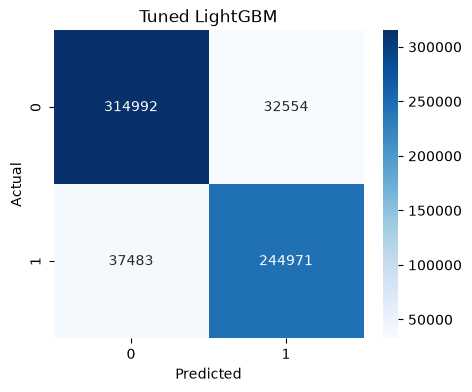

Tuned XGBoost
Accuracy : 0.8887
Precision: 0.8823
Recall   : 0.8676
F1 Score : 0.8748
ROC-AUC  : 0.9552

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    347546
           1       0.88      0.87      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000



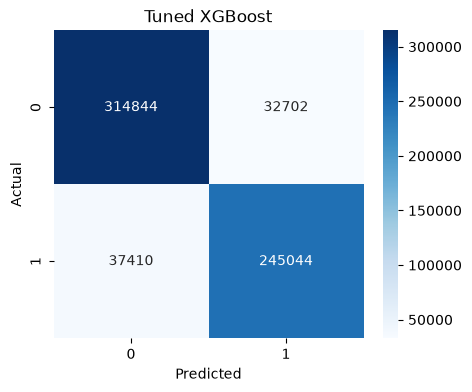

Ultimate Blend
Accuracy : 0.8888
Precision: 0.8825
Recall   : 0.8674
F1 Score : 0.8749
ROC-AUC  : 0.9554

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.91      0.90    347546
           1       0.88      0.87      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000



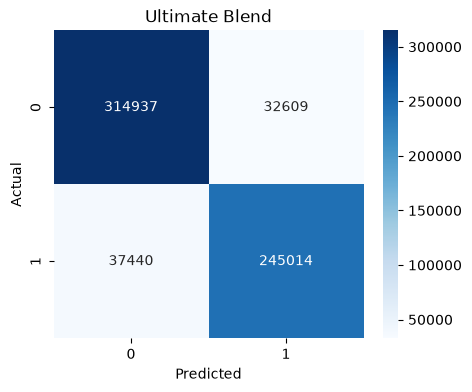


Model Comparison


,Accuracy,Precision,Recall,F1 Score,ROC AUC
LightGBM,0.8888,0.8827,0.8673,0.8749,0.9554
XGBoost,0.8887,0.8823,0.8676,0.8748,0.9552
Ultimate Blend,0.8888,0.8825,0.8674,0.8749,0.9554


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(y_true, probabilities, model_name):

    predictions = (probabilities >= 0.5).astype(int)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy_score(y_true, predictions):.4f}")
    print(f"Precision: {precision_score(y_true, predictions):.4f}")
    print(f"Recall   : {recall_score(y_true, predictions):.4f}")
    print(f"F1 Score : {f1_score(y_true, predictions):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, probabilities):.4f}")

    print("\nClassification Report")
    print(classification_report(y_true, predictions))

    cm = confusion_matrix(y_true, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model_name)
    plt.show()

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 Score": f1_score(y_true, predictions),
        "ROC AUC": roc_auc_score(y_true, probabilities)
    }


# Evaluate models
lgb_results = evaluate_model(y, tuned_lgb_oof, "Tuned LightGBM")
xgb_results = evaluate_model(y, tuned_xgb_oof, "Tuned XGBoost")
blend_results = evaluate_model(y, ultimate_blend_oof, "Ultimate Blend")

# Comparison table
results = pd.DataFrame(
    [lgb_results, xgb_results, blend_results],
    index=["LightGBM", "XGBoost", "Ultimate Blend"]
)

print("\nModel Comparison")
display(results.round(4))

# Final Model Training on Full Data & Artifact Export

In [6]:
import joblib
import lightgbm as lgb

print("--- Training Final Production Model on Full Dataset ---")

# 1. Train tuned LightGBM on 100% of the training data
final_model = lgb.LGBMClassifier(**tuned_lgb_params)
final_model.fit(X, y)

# 2. Package model along with feature names to ensure compatibility
model_payload = {"model": final_model, "features": list(X.columns)}

# 3. Export for Streamlit
joblib.dump(model_payload, "heart_disease_model.joblib")
print("✅ Successfully exported 'heart_disease_model.joblib'!")

--- Training Final Production Model on Full Dataset ---
✅ Successfully exported 'heart_disease_model.joblib'!
